# 2025/03/17 - Kraken 2 - PFP 16 - Results

## Summary 

We aim to check what's the result of running Kraken2 with a PFP database. Previous results were able to classify around 20% of the data, but most of the classified sequences were associated to organisms that were not relevant for our research —and none to hosts.

Now, considering that our database should be enriched in host sequences, we should be able to appreciate some hits in the planta, fungi and protozoa domains.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import numpy as np 
import taxoniq
import tqdm

In [3]:
kraken2_out = pd.read_csv("../results/2025-03-06.kraken2-run/PV64.pfp16.kraken2.csv", sep="\t", header=None, index_col=None, names=['is_classified', 'seq_id',  'taxonid', '_1', '_2'])
kraken2_out[:10]

,is_classified,seq_id,taxonid,_1,_2
0,U,J00148:56:HM5WHBBXX:1:1101:1296:1244,0,151|132,0:21 A:88 0:8 |:| A:66 0:22 A:10
1,U,J00148:56:HM5WHBBXX:1:1101:2656:1244,0,151|132,0:21 A:94 0:2 |:| A:66 0:21 A:11
2,U,J00148:56:HM5WHBBXX:1:1101:2717:1244,0,151|132,0:21 A:94 0:2 |:| A:66 0:21 A:11
3,U,J00148:56:HM5WHBBXX:1:1101:2757:1244,0,151|132,0:21 A:94 0:2 |:| A:66 0:21 A:11
4,U,J00148:56:HM5WHBBXX:1:1101:3650:1244,0,151|132,0:21 A:94 1437201:2 |:| A:66 0:21 A:11
5,U,J00148:56:HM5WHBBXX:1:1101:7202:1244,0,151|124,0:12 A:105 |:| A:66 0:13 A:11
6,U,J00148:56:HM5WHBBXX:1:1101:13210:1244,0,151|124,0:10 A:107 |:| A:69 0:9 A:12
7,U,J00148:56:HM5WHBBXX:1:1101:13738:1244,0,151|124,0:10 A:107 |:| A:69 0:9 A:12
8,U,J00148:56:HM5WHBBXX:1:1101:15483:1244,0,151|124,0:10 A:107 |:| A:69 0:6 A:15
9,U,J00148:56:HM5WHBBXX:1:1101:17066:1244,0,139|124,0:10 A:95 |:| A:69 0:6 A:15


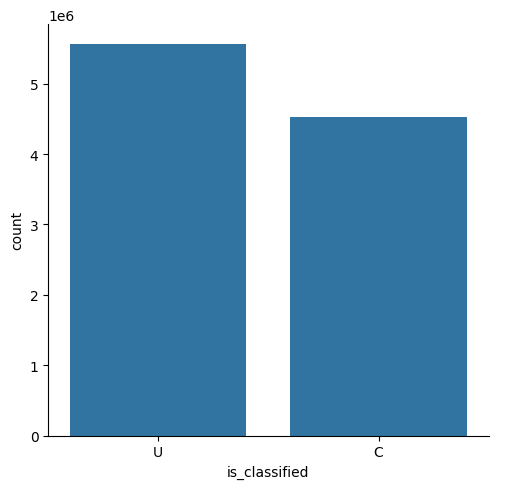

In [4]:
g = sns.catplot(kraken2_out.value_counts(subset=['is_classified']).reset_index(), x='is_classified', y='count', kind='bar')
# g.axes[0, 0].set_yscale('log')

In [5]:
kraken2_classified = kraken2_out.query('is_classified == "C"').copy()

In [6]:
kraken2_classified_bycount = kraken2_classified.value_counts(['taxonid']).reset_index()
kraken2_classified_bycount['position'] = np.arange(len(kraken2_classified_bycount))

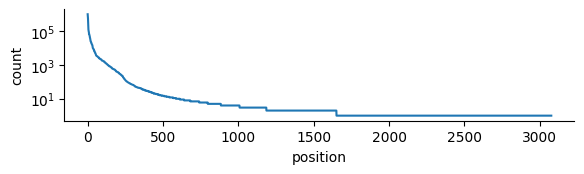

In [7]:
g = sns.relplot(x='position', y='count', data=kraken2_classified_bycount, kind='line', height=2.0, aspect=3.0)
g.axes[0,0].set_yscale('log')

In [8]:
kraken2_classified_bycount[:20]


,taxonid,count,position
0,1437201,1024080,0
1,1437183,801490,1
2,4210,588880,2
3,4236,300530,3
4,4232,205189,4
5,131567,126195,5
6,59895,107192,6
7,72917,96200,7
8,71274,88527,8
9,3469,68875,9


In [9]:
kraken2_classified_bycount_top = kraken2_classified_bycount[:50].copy()
kraken2_classified_bycount_top['logcount'] = kraken2_classified_bycount_top['count'].apply(np.log10)
kraken2_classified_bycount_top['scientific name'] = kraken2_classified_bycount_top['taxonid'].apply(
    lambda x: taxoniq.Taxon(x).scientific_name
)

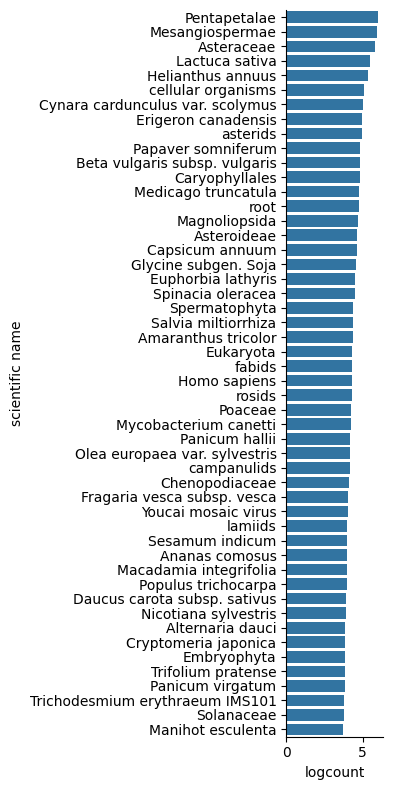

In [10]:
sns.catplot(y='scientific name', x='logcount', data=kraken2_classified_bycount_top, height=8.0, aspect=0.5, kind='bar')

In [11]:
for i, x in enumerate(list(reversed(taxoniq.Taxon(401937).ranked_lineage))):
    print(("\t |--> " * i) + x.scientific_name)

Eukaryota
	 |--> Viridiplantae
	 |--> 	 |--> Streptophyta
	 |--> 	 |--> 	 |--> Magnoliopsida
	 |--> 	 |--> 	 |--> 	 |--> Asterales
	 |--> 	 |--> 	 |--> 	 |--> 	 |--> Asteraceae
	 |--> 	 |--> 	 |--> 	 |--> 	 |--> 	 |--> Artemisia
	 |--> 	 |--> 	 |--> 	 |--> 	 |--> 	 |--> 	 |--> Artemisia superba


! bingo

In [12]:
def obtain_domain(taxonid):
    try:
        return taxoniq.Taxon(taxonid).ranked_lineage[-1].scientific_name
    except IndexError:
        return "unknown"
    except KeyError:
        return "unknown"

def obtain_scientific_name(taxonid):
    try:
        return taxoniq.Taxon(taxonid).scientific_name
    except IndexError:
        return "unknown"
    except KeyError:
        return "unknown"


In [13]:
kraken2_classified_bycount['domain'] = kraken2_classified_bycount['taxonid'].apply(obtain_domain)
kraken2_classified_bycount['scientific_name'] = kraken2_classified_bycount['taxonid'].apply(obtain_scientific_name)

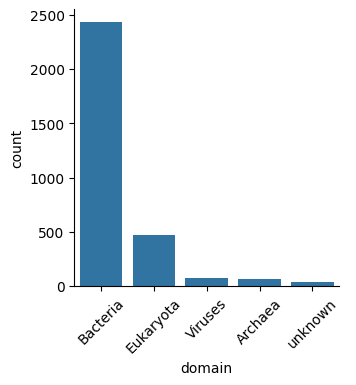

In [14]:
g = sns.catplot(
    data=kraken2_classified_bycount.value_counts(subset=['domain']).reset_index(),
    x='domain', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=45)

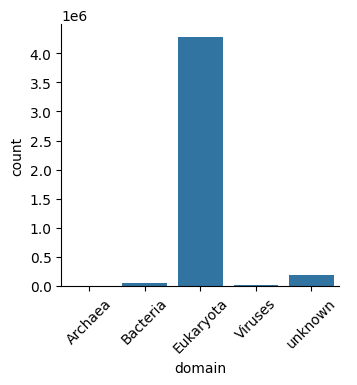

In [15]:
g = sns.catplot(
    data=kraken2_classified_bycount[['domain', 'count']].groupby('domain', as_index=False).sum(),
    x='domain', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=45)

In [16]:
kraken2_classified_bycount

,taxonid,count,position,domain,scientific_name
0,1437201,1024080,0,Eukaryota,Pentapetalae
1,1437183,801490,1,Eukaryota,Mesangiospermae
2,4210,588880,2,Eukaryota,Asteraceae
3,4236,300530,3,Eukaryota,Lactuca sativa
4,4232,205189,4,Eukaryota,Helianthus annuus
...,...,...,...,...,...
3072,1247726,1,3072,Bacteria,Advenella mimigardefordensis DPN7
3073,1246301,1,3073,Bacteria,Variovorax paradoxus B4
3074,1245436,1,3074,Bacteria,Paraburkholderia kirstenboschensis
3075,1241982,1,3075,Bacteria,Chryseobacterium nakagawai


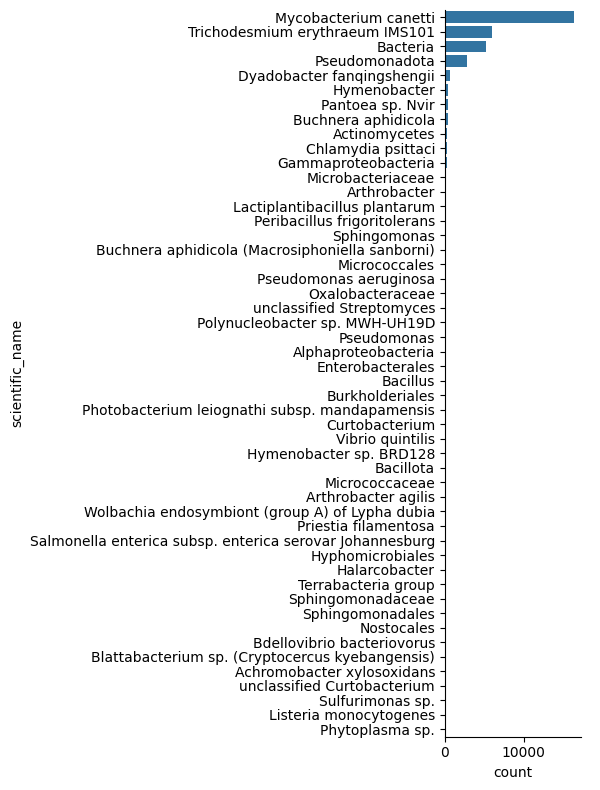

In [17]:
sns.catplot(
    y='scientific_name', x='count', 
    data=kraken2_classified_bycount.query('domain == "Bacteria"')[:50], 
    height=8.0, aspect=0.75, kind='bar'
)

## Classification of reads

In [18]:
taxonomy = []
for item in tqdm.tqdm(kraken2_out['taxonid'].unique()):
    try:
        t = taxoniq.Taxon(item)
        domain = t.ranked_lineage[-1].scientific_name
        kingdom = t.ranked_lineage[-2].scientific_name
    except KeyError:
        taxonomy.append(dict(taxonid=item, species_name="unknown", domain="unknown", kingdom="unknown"))
        continue
    except IndexError:
        taxonomy.append(dict(taxonid=item, species_name=t.scientific_name, domain="unknown", kingdom="unknown"))
        continue
    taxonomy.append(
        dict(
            taxonid=item, 
            species_name=t.scientific_name,
            domain=domain,
            kingdom=kingdom
        )
    )
taxonomy = pd.DataFrame.from_records(taxonomy)

  0%|          | 0/3078 [00:00<?, ?it/s]

100%|██████████| 3078/3078 [00:00<00:00, 6573.13it/s]


In [19]:
kraken2_out = pd.merge(kraken2_out, taxonomy, on='taxonid')

In [25]:
kraken2_out.query('domain == "unknown" or domain == "Bacteria"')[['seq_id']].to_csv("../results/2025-03-18-pv064-kraken2-mmseqs2/ids.txt", sep="\t", index=None, header=None)

In [29]:
kraken2_out.query('domain == "unknown" or domain == "Bacteria"')

,is_classified,seq_id,taxonid,_1,_2,species_name,domain,kingdom
0,U,J00148:56:HM5WHBBXX:1:1101:1296:1244,0,151|132,0:21 A:88 0:8 |:| A:66 0:22 A:10,unknown,unknown,unknown
1,U,J00148:56:HM5WHBBXX:1:1101:2656:1244,0,151|132,0:21 A:94 0:2 |:| A:66 0:21 A:11,unknown,unknown,unknown
2,U,J00148:56:HM5WHBBXX:1:1101:2717:1244,0,151|132,0:21 A:94 0:2 |:| A:66 0:21 A:11,unknown,unknown,unknown
3,U,J00148:56:HM5WHBBXX:1:1101:2757:1244,0,151|132,0:21 A:94 0:2 |:| A:66 0:21 A:11,unknown,unknown,unknown
4,U,J00148:56:HM5WHBBXX:1:1101:3650:1244,0,151|132,0:21 A:94 1437201:2 |:| A:66 0:21 A:11,unknown,unknown,unknown
...,...,...,...,...,...,...,...,...
10087149,U,J00148:56:HM5WHBBXX:2:2228:26068:48808,0,151|151,0:117 |:| 0:85 4527:5 0:27,unknown,unknown,unknown
10087153,C,J00148:56:HM5WHBBXX:2:2228:25347:48825,1,32|151,|:| 0:10 1:5 0:3 1:3 0:96,root,unknown,unknown
10087154,U,J00148:56:HM5WHBBXX:2:2228:27194:48825,0,151|151,0:117 |:| 0:117,unknown,unknown,unknown
10087155,U,J00148:56:HM5WHBBXX:2:2228:28655:48825,0,151|151,0:117 |:| 0:117,unknown,unknown,unknown


In [10]:
check = pd.read_csv("/home/bcz/research/miripvir25/results/2025-03-18-pv064-kraken2-mmseqs2/names.txt", header=None, names=['raw'])
check['seq_id'] = check['raw'].apply(lambda x: x.split(' ')[0])
check['read'] = check['raw'].apply(lambda x: x.split(' ')[1].split(':')[0])
# check = check.drop_duplicates(subset='seq_id', keep='first')
check

,raw,seq_id,read
0,@J00148:56:HM5WHBBXX:1:1101:7496:1297 1:N:0:GC...,@J00148:56:HM5WHBBXX:1:1101:7496:1297,1
1,@J00148:56:HM5WHBBXX:1:1101:9891:1297 1:N:0:GC...,@J00148:56:HM5WHBBXX:1:1101:9891:1297,1
2,@J00148:56:HM5WHBBXX:1:1101:13261:1297 1:N:0:G...,@J00148:56:HM5WHBBXX:1:1101:13261:1297,1
3,@J00148:56:HM5WHBBXX:1:1101:15392:1297 1:N:0:G...,@J00148:56:HM5WHBBXX:1:1101:15392:1297,1
4,@J00148:56:HM5WHBBXX:1:1101:24830:1297 1:N:0:G...,@J00148:56:HM5WHBBXX:1:1101:24830:1297,1
...,...,...,...
11301955,@J00148:56:HM5WHBBXX:2:2228:25784:48808 2:N:0:...,@J00148:56:HM5WHBBXX:2:2228:25784:48808,2
11301956,@J00148:56:HM5WHBBXX:2:2228:26068:48808 2:N:0:...,@J00148:56:HM5WHBBXX:2:2228:26068:48808,2
11301957,@J00148:56:HM5WHBBXX:2:2228:27194:48825 2:N:0:...,@J00148:56:HM5WHBBXX:2:2228:27194:48825,2
11301958,@J00148:56:HM5WHBBXX:2:2228:28655:48825 2:N:0:...,@J00148:56:HM5WHBBXX:2:2228:28655:48825,2


In [11]:
check.pivot(index='seq_id', columns='read', values='raw')

read,1,2
seq_id,,
@J00148:56:HM5WHBBXX:1:1101:10003:1525,@J00148:56:HM5WHBBXX:1:1101:10003:1525 1:N:0:G...,@J00148:56:HM5WHBBXX:1:1101:10003:1525 2:N:0:G...
@J00148:56:HM5WHBBXX:1:1101:10003:28147,@J00148:56:HM5WHBBXX:1:1101:10003:28147 1:N:0:...,@J00148:56:HM5WHBBXX:1:1101:10003:28147 2:N:0:...
@J00148:56:HM5WHBBXX:1:1101:10003:33246,@J00148:56:HM5WHBBXX:1:1101:10003:33246 1:N:0:...,@J00148:56:HM5WHBBXX:1:1101:10003:33246 2:N:0:...
@J00148:56:HM5WHBBXX:1:1101:10003:3424,@J00148:56:HM5WHBBXX:1:1101:10003:3424 1:N:0:G...,@J00148:56:HM5WHBBXX:1:1101:10003:3424 2:N:0:G...
@J00148:56:HM5WHBBXX:1:1101:10003:36446,@J00148:56:HM5WHBBXX:1:1101:10003:36446 1:N:0:...,@J00148:56:HM5WHBBXX:1:1101:10003:36446 2:N:0:...
...,...,...
@J00148:56:HM5WHBBXX:2:2228:9993:16700,@J00148:56:HM5WHBBXX:2:2228:9993:16700 1:N:0:G...,@J00148:56:HM5WHBBXX:2:2228:9993:16700 2:N:0:G...
@J00148:56:HM5WHBBXX:2:2228:9993:35655,@J00148:56:HM5WHBBXX:2:2228:9993:35655 1:N:0:G...,@J00148:56:HM5WHBBXX:2:2228:9993:35655 2:N:0:G...
@J00148:56:HM5WHBBXX:2:2228:9993:40051,@J00148:56:HM5WHBBXX:2:2228:9993:40051 1:N:0:G...,@J00148:56:HM5WHBBXX:2:2228:9993:40051 2:N:0:G...
